# Red Wine Quality Analysis

### INTRODUCTION


**Goal:** This project analyses the Red Wine Quality dataset to understand which variables most influence Portuguese red wine quality scores. The goal is to build an explanatory statistical model that identifies variables that contribute to quality scores. 

**Data Source:** The dataset comes from the UCI Machine Learning Repository and has also been made available on Kaggle. It was originally compiled by Paulo Cortez et al. (2009)  as part of a research project on modeling wine preferences.

**Variables:** The dataset consists of 12 variables in total. 11 input variables were collected from physicochemical tests of the wine and 1 output variable based on sensory evaluation data by wine experts (which is the target variable for this analysis).

<u>Input variables (Physicochemical tests):</u>
1. **Fixed Acidity** (g/L of tartaric acid): Non-volatile acids that do not evaporate easily, important for taste and stability.
2. **Volatile Acidity** (g/L of acetic acid): High levels can give wine a vinegar-like taste.
3. **Citric Acid** (g/L): A natural acid that adds freshness and flavour.
4. **Residual Sugar** (g/L): Sugar left after fermentation which affects sweetness. 
5. **Chlorides** (g/L of sodium chloride): Measures salt content in the wine.
6. **Free Sulfur Dioxide** (mg/L): The active SO₂ that protects wine from oxidation and microbial growth.
7. **Total Sulfur Dioxide** (mg/L): The combined amount of free and bound SO₂.
8. **Density** (g/cm3): Compares wine’s heaviness to water.
9. **pH**(0 to 14): Measures acidity.
10. **Sulphates** (g/L of potassium sulphate): Added to wines as preservatives and antioxidants to improve shelf life.
11. **Alcohol** (% by volume): the percent alcohol content of the wine. 

<u>Output variable (sensory data):</u>

12. **Quality** (1 to 10): A wine score given by wine experts based on sensory tests.

**Notebook Structure:** 
1. Data Structure
2. Data Preparation
3. Exploratory Data Analysis 
4. Hypotheses
5. Test Data 
6. Model Preparation 
7. Model Fitting
8. Hypothesis Results
9. Model Validation
10. Conclusion and Improvements


### 1. DATA STRUCTURE

**1.1 Loading Libraries & Dataset**

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.regressionplots import plot_partregress
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('winequality-red.csv')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [214]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


**1.2 Sample Size**

In [215]:
df.shape

(1599, 12)

We can see there are total 1599 observations with 12 different feature variables present. 

**1.3 Variables**

In [216]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In data preparation stage, I will rename the columns with underscores between the spaces. 

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Every variable is quantitative. 

### 2. DATA PREPARATION

**2.1 Missing Values**

In [218]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

There are no missing values. 

**2.2 Duplicates**

In [219]:
df.duplicated().sum()

np.int64(240)

There are 240 duplicates. After analysing the duplicate entries, I decided to keep them as they appear to be valid distinct observations rather than data errors. Multiple wine samples sharing identical features is reasonable given these could be different bottles from the same batch/vintage. 

**2.3 Column Rename**

In [220]:
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.replace(" ", "_")

for i, col in enumerate(df_clean.columns, 1):
    print(f"{i:2d}. {col}")

 1. fixed_acidity
 2. volatile_acidity
 3. citric_acid
 4. residual_sugar
 5. chlorides
 6. free_sulfur_dioxide
 7. total_sulfur_dioxide
 8. density
 9. pH
10. sulphates
11. alcohol
12. quality


**2.4 Outlier Detection**

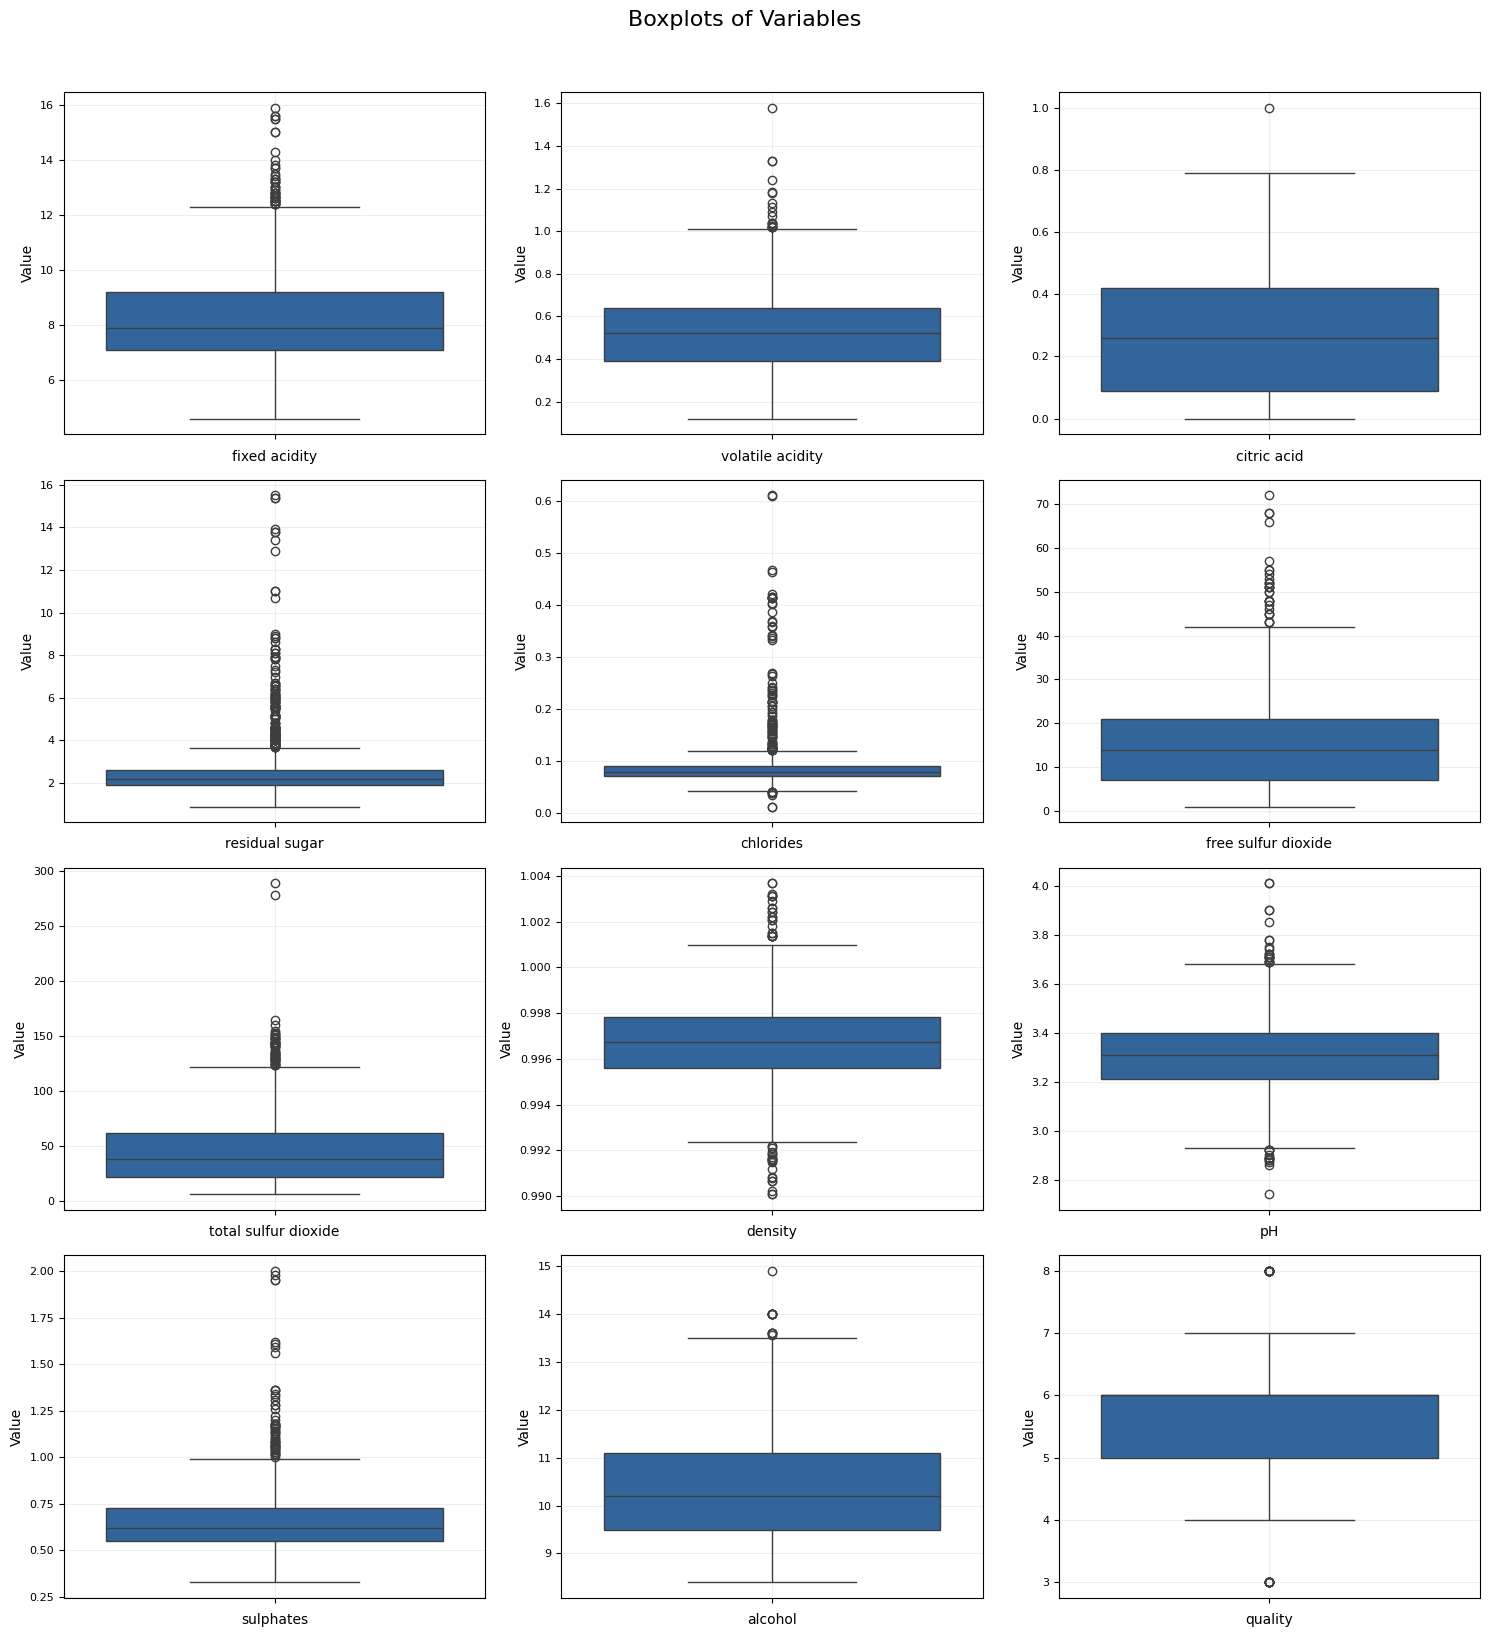

In [221]:
n_vars = len(df_clean.columns)
n_rows = (n_vars + 2) // 3  

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))
fig.suptitle('Boxplots of Variables', fontsize=16, y=1.02)
axes = axes.ravel()  

plot_df = df_clean.copy()
plot_df.columns = plot_df.columns.str.replace('_', ' ')

for idx, column in enumerate(plot_df.columns):
    sns.boxplot(data=plot_df, y=column, ax=axes[idx], color='#2166AC')  
    axes[idx].tick_params(labelsize=8)
    axes[idx].grid(True, alpha=0.2)
    axes[idx].set_ylabel('Value')  
    axes[idx].set_xlabel(column)   

for idx in range(len(plot_df.columns), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

The boxplot shows several outliers, especially for chlorides, sulphates, residual sugar and free/total sulfur dioxide. I have chosen to keep these outliers for now as they may be meaningful for wine quality, but will reassess their impact during modelling if they significantly affect our results.

**2.5 Summary of Variables**

In [222]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile_acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric_acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual_sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free_sulfur_dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total_sulfur_dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


### 3. EXPLORATORY DATA ANALYSIS (EDA)

**3.1 Distribution of Variables**

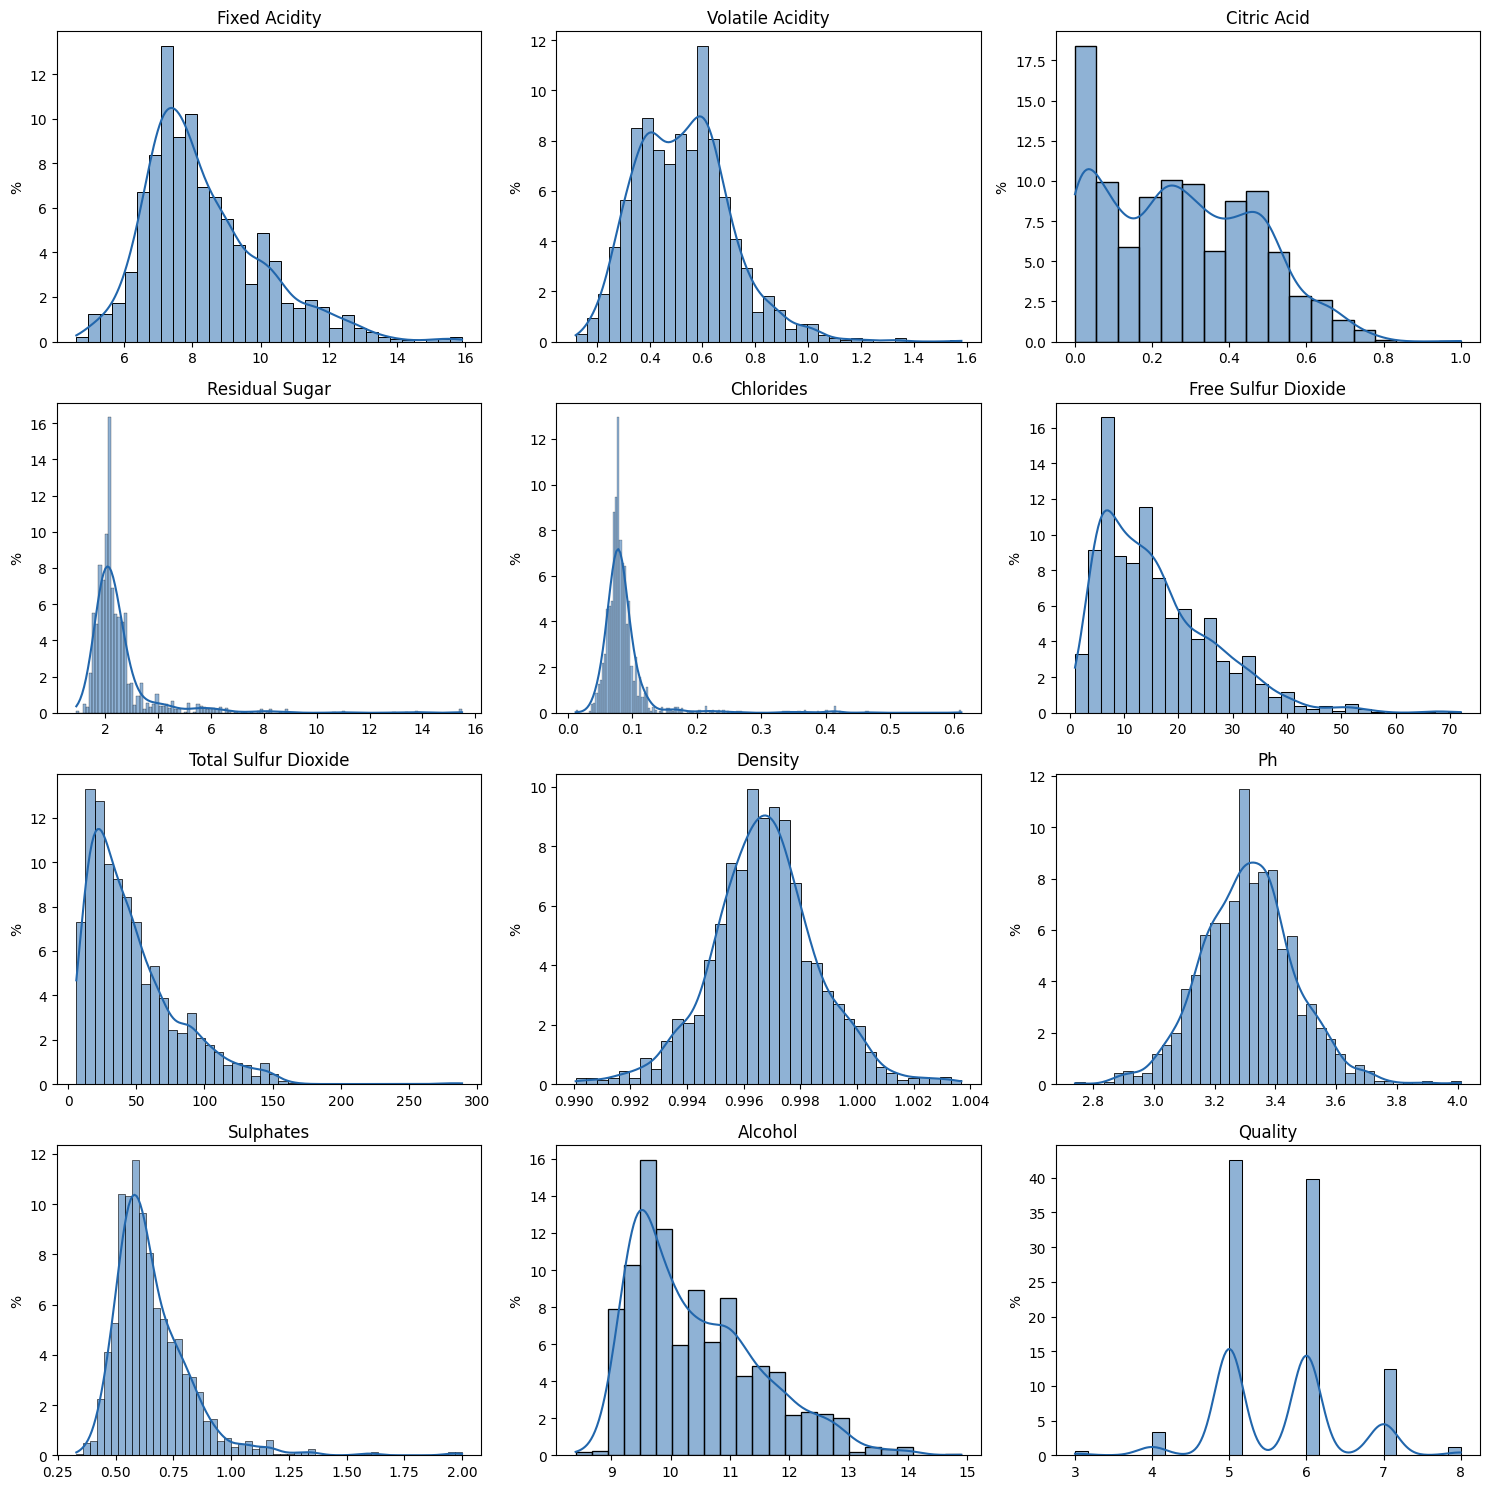

In [223]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.ravel()

for idx, column in enumerate(df_clean.columns):
    sns.histplot(
        data=df_clean, 
        x=column, 
        ax=axes[idx], 
        kde=True, 
        color='#2166AC',
        stat='percent'  
    )
    axes[idx].set_title(column.replace('_', ' ').title())
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('%')  

plt.tight_layout()
plt.show()

**Normal Distributions**:
- Density
- pH
- Quality (bimodal)

**Moderately Right-Skewed**:
- Fixed Acidity
- Volatile Acidity
- Citric Acid
- Alcohol
- Sulphates

**Heavily Right-Skewed**:
- Residual Sugar
- Chlorides
- Free Sulfur Dioxide
- Total Sulfur Dioxide

**3.2 Boxplots of Features by Quality**

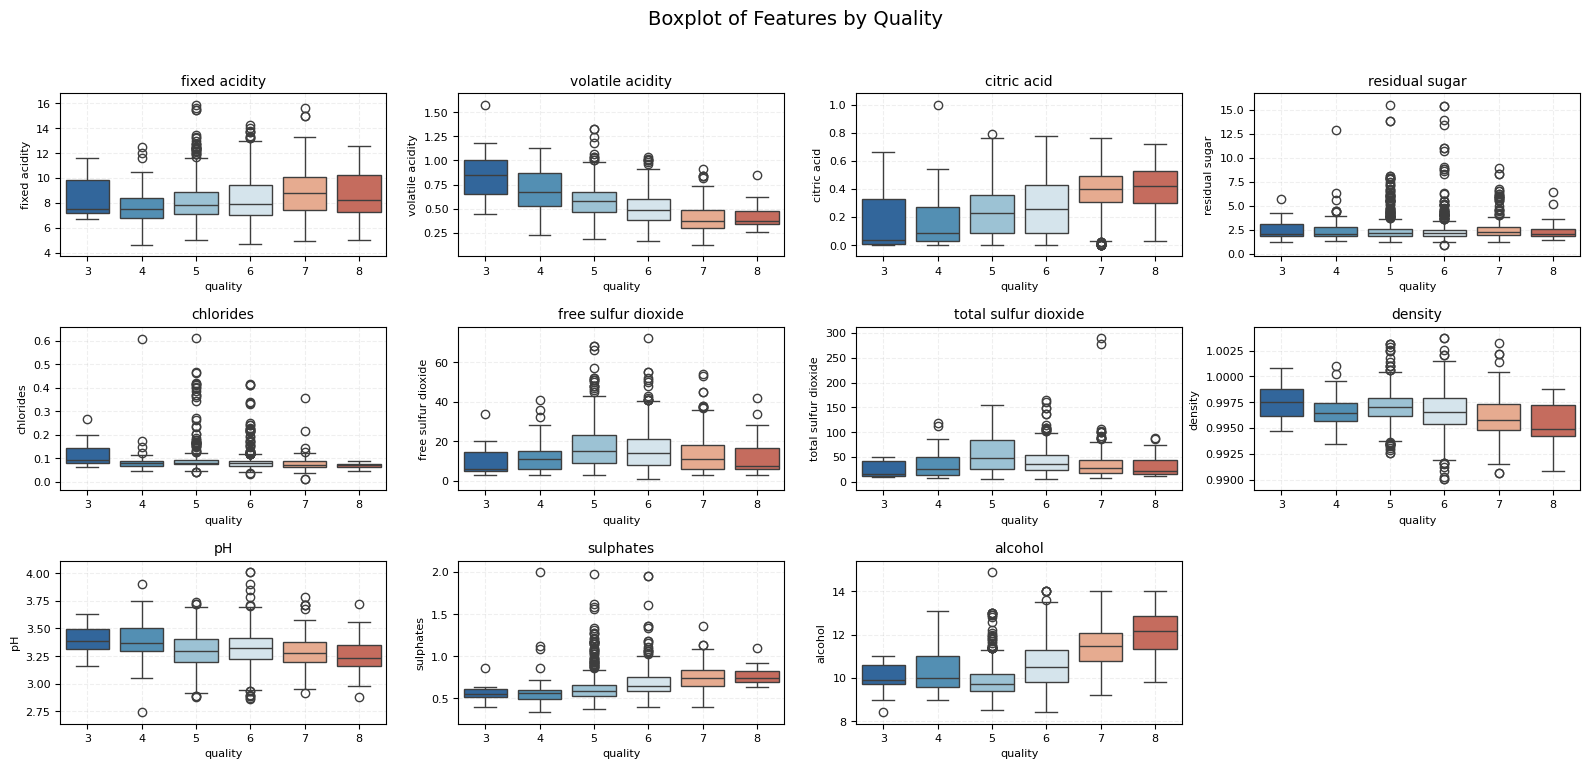

In [224]:
features = [col for col in df_clean.columns if col not in ['quality', 'quality_percentile']]
fig, axes = plt.subplots((len(features) + 3) // 4, 4, figsize=(16, 7.5))

for idx, (feature, ax) in enumerate(zip(features, axes.ravel())):
    sns.boxplot(x='quality', y=feature, data=df_clean, 
                palette=['#2166AC', '#4393C3', '#92C5DE', '#D1E5F0', '#F4A582', '#D6604D'],
                ax=ax)
    
    data_range = df_clean[feature].max() - df_clean[feature].min()
    margin = data_range * 0.08
    ax.set_ylim(df_clean[feature].min() - margin, df_clean[feature].max() + margin)
    ax.set_box_aspect(0.5)
    
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.set_title(feature.replace('_', ' '), fontsize=10)
    ax.set_xlabel('quality', fontsize=8)
    ax.set_ylabel(feature.replace('_', ' '), fontsize=8)
    ax.tick_params(labelsize=8)

for ax in axes.ravel()[len(features):]: ax.remove()
plt.suptitle("Boxplot of Features by Quality", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

These boxplots provide visual insights into potential predictive relationships before modeling. From these preliminary boxplots, three key variables show strong linear relationships with wine quality: alcohol (positive), volatile acidity (negative), sulphates (positive) and citric acid (positive). Fixed acidity, pH, and density display weak linear relationships. Free sulfur dioxide, total sulfur dioxide, chlorides and residual sugar demonstrate minimal to no clear relationship with quality.




**3.3 Correlation Matrix Heatmap**

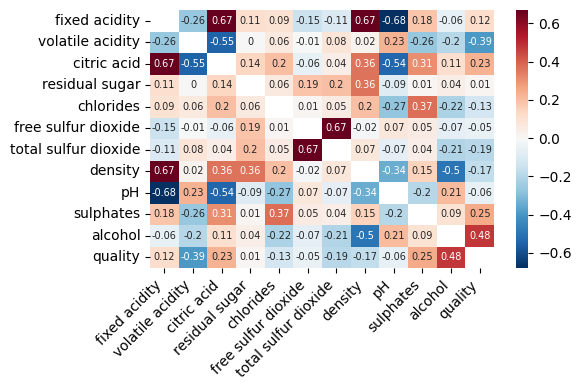

In [225]:
correlation_matrix = df_clean.corr().round(2)
correlation_matrix *= 1 + np.diag(np.nan*np.ones(len(df_clean.columns)))


plt.figure(figsize=(6, 4))
sns.heatmap(
    data=correlation_matrix,
    annot=True,
    cmap="RdBu_r",
    annot_kws={'size': 7},  
    xticklabels=[col.replace('_', ' ') for col in df_clean.columns],  
    yticklabels=[col.replace('_', ' ') for col in df_clean.columns]   
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the correlation heatmap analysis of wine characteristics, we can see that there are correlations between the dependent variable (quality) and each of the indepedent variables. The strongest correlations with quality are positive for alcohol (+0.48) and negative for volatile acidity (-0.39). It is also evident that the explanatory variables are correlated with each other, sometimes strongly (e.g., the correlation between fixed acidity and citric acid is +0.67, and between pH and fixed acidity is -0.68).

The presence of multiple correlations between independent variables suggests potential multicollinearity, which would be important to consider in any statistical modeling of wine quality.


**3.4 Multicollinearity Detection**

In [226]:
def calculate_vif(df_clean):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_clean.columns
    vif_data["VIF"] = [variance_inflation_factor(df_clean.values, i) 
                       for i in range(df_clean.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

X = df_clean.drop('quality', axis=1)  
vif_results = calculate_vif(X)

print(vif_results.to_string(index=False))

             Feature         VIF
             density 1479.287209
                  pH 1070.967685
             alcohol  124.394866
       fixed_acidity   74.452265
           sulphates   21.590621
    volatile_acidity   17.060026
         citric_acid    9.183495
           chlorides    6.554877
total_sulfur_dioxide    6.519699
 free_sulfur_dioxide    6.442682
      residual_sugar    4.662992


The VIF values seem extremelty high which likely stem from features with different units or scales. To resolve this, I have log transformed the skewed features and standardised the variables. 


In [227]:
df_vif = df_clean.copy()

skewed_features = ['residual_sugar', 'chlorides', 'free_sulfur_dioxide', 
                   'total_sulfur_dioxide', 'sulphates']
for feature in skewed_features:
    df_vif[feature] = np.log1p(df_vif[feature])

scaler = StandardScaler()
features_to_scale = [col for col in df_vif.columns if col != 'quality']
df_vif[features_to_scale] = scaler.fit_transform(df_vif[features_to_scale])

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) 
                       for i in range(df.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

X_vif = df_vif.drop('quality', axis=1)
vif_results_scaled = calculate_vif(X_vif)

print("VIF after scaling and transformation:")
print(vif_results_scaled.to_string(index=False))

VIF after scaling and transformation:
             Feature      VIF
       fixed_acidity 7.979574
             density 7.292152
             alcohol 3.411378
                  pH 3.339562
total_sulfur_dioxide 3.123812
         citric_acid 3.042923
 free_sulfur_dioxide 2.867791
      residual_sugar 1.932594
    volatile_acidity 1.765355
           chlorides 1.451208
           sulphates 1.444913


The Variance Inflation Factor (VIF) analysis after scaling and transformation shows improved multicollinearity metrics among the wine characteristics:
* Fixed acidity and density show the highest VIF values (7.98 and 7.29 respectively), indicating moderate multicollinearity, though significantly improved from their original values.
* Alcohol, pH, total sulfur dioxide, and citric acid show moderate VIF values ranging from 3.04 to 3.41, suggesting acceptable levels of correlation with other features.
* Free sulfur dioxide, residual sugar, volatile acidity, chlorides, and sulphates demonstrate low VIF values (below 3), indicating minimal multicollinearity concerns.

The scaling and transformation procedures have successfully addressed the severe multicollinearity issues observed in the original data, with all VIF values now falling below the critical threshold of 10. In the model preparation phase, these improvements will be maintained by applying log transformation and scaling to both training and test datasets. 

 ### 4. HYPOTHESES


Exploratory analysis revealed two variables with strong relationships to wine quality, leading to these testable hypotheses:

Alcohol and Quality

* Null Hypothesis (H0): Alcohol content does not significantly affect wine quality.
* Alternative Hypothesis (H1): Higher alcohol content is associated with higher wine quality.

Volatile Acidity and Quality

* Null Hypothesis (H0): Volatile acidity levels do not significantly affect wine quality.
* Alternative Hypothesis (H1): Higher volatile acidity is associated with lower wine quality.



### 5. TEST DATA 

In [228]:
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=y)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

Training set: 1279 samples (80.0%)
Test set: 320 samples (20.0%)


We randomly set aside 20% of the data. After we build and explain our model, we’ll use this test data assess the model performance.  

### 6. MODEL PREPARATION

**6.1 Variable Selection**

Include:
* Alcohol: strongest positive correlation with quality and clear linear relationship in scatter plots
* Volatile Acidity: strong negative correlation with quality
* Residual Sugar: very low multicollinearity and important for wine sweetness perception
* Fixed acidity: primary acid structure in wine and influences overall taste profile
* Sulphates: acts as wine preservative and affects wine aroma
* Citric acid: moderate positive correlation from EDA and contributes to wine freshness
* Chlorides: contributes to saltiness and influences taste
* Total sulfur dioxide: overall preservative content and oore comprehensive measure of SO2

Exclude:
* Density: one of the highest multicollinearity and information captured by other chemical properties (e.g. fixed acidity and citric acid)
* pH: information already represented by fixed acidity
* Free sulfur dioxide: component of total sulfur dioxide, redundant when total SO2 is included and highly correlated with total sulfur dioxide. 

**6.2 Transformations**

Given that most of the variables are moderately to strongly right-skewed, I have applied a log transformation to reduce skewness and better meet the assumptions of linear modelling.

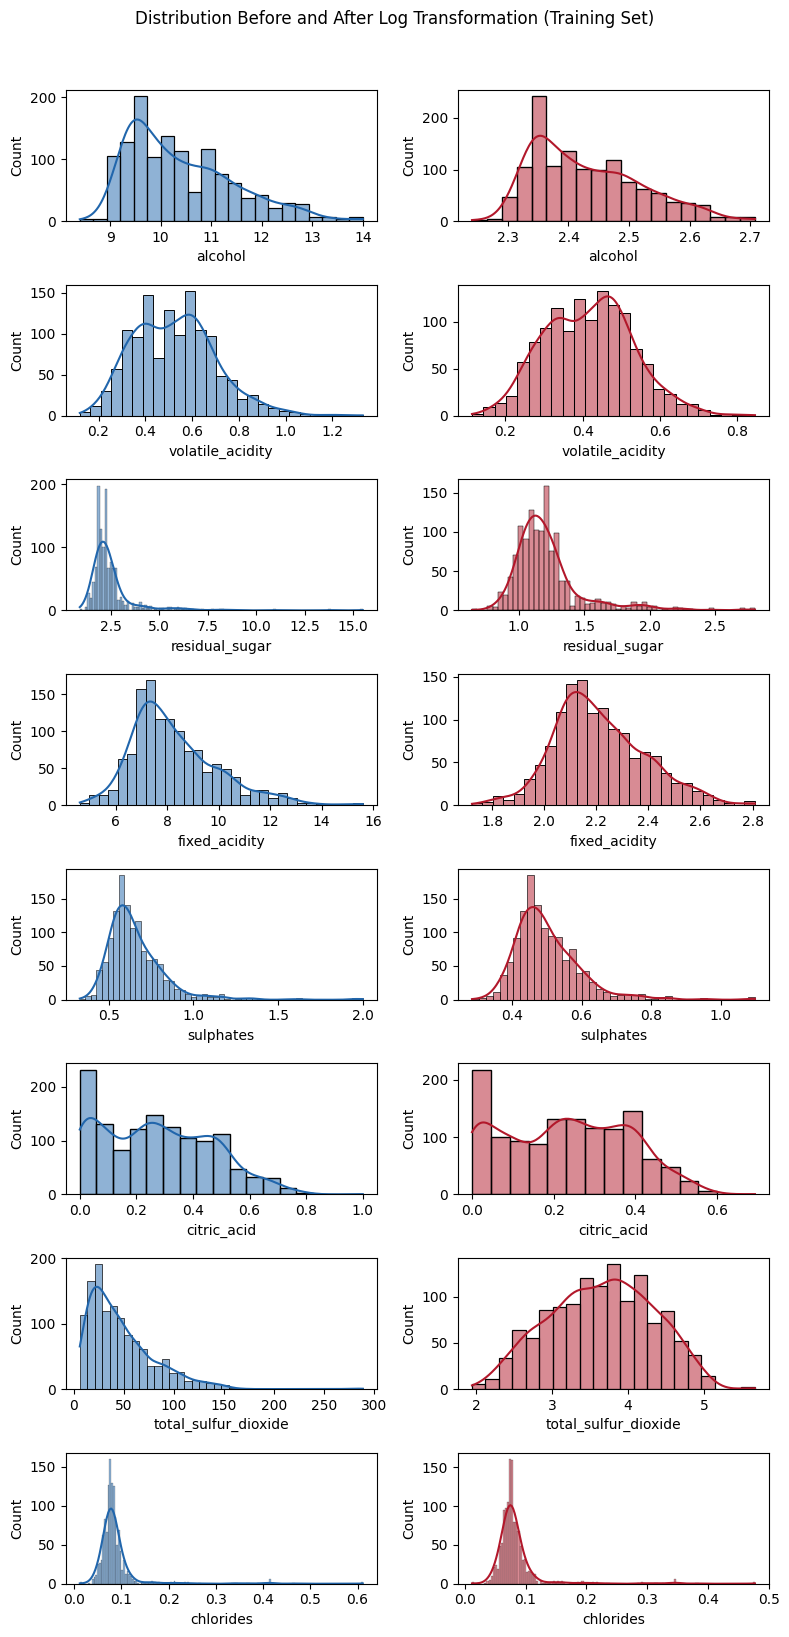

In [229]:
def log_transform_features(df_clean, columns):
    df_transformed = df_clean.copy()
    for column in columns:
        df_transformed[column] = np.log1p(df_transformed[column])
    return df_transformed

columns_to_transform = [
    'alcohol',          
    'volatile_acidity',
    'residual_sugar',
    'fixed_acidity',
    'sulphates',
    'citric_acid',
    'total_sulfur_dioxide',
    'chlorides'
]

X_train_transformed = log_transform_features(X_train, columns_to_transform)
X_test_transformed = log_transform_features(X_test, columns_to_transform)


fig, axes = plt.subplots(8, 2, figsize=(8, 16))  
fig.suptitle('Distribution Before and After Log Transformation (Training Set)', fontsize=12, y=1.02)

for idx, column in enumerate(columns_to_transform):  
 
    sns.histplot(data=X_train, x=column, ax=axes[idx, 0], kde=True, color='#2166AC')
    sns.histplot(data=X_train_transformed, x=column, ax=axes[idx, 1], kde=True, color='#B2182B')
   

plt.tight_layout()
plt.show()

**6.3 Standardisation**

Standard Scaler transforms our features to a common scale (mean=0, standard deviation=1), ensuring fair comparison between variables measured in different units and preventing features with larger scales from dominating the analysis. As shown in the summary statistics table below, all features have been successfully standardised to this common scale.

In [230]:
X_train_scaled = X_train_transformed.copy()
X_test_scaled = X_test_transformed.copy()

scaler = StandardScaler()
X_train_scaled[columns_to_transform] = scaler.fit_transform(X_train_transformed[columns_to_transform])
X_test_scaled[columns_to_transform] = scaler.transform(X_test_transformed[columns_to_transform])

print(X_train_scaled[columns_to_transform].describe().round(3))

        alcohol  volatile_acidity  residual_sugar  fixed_acidity  sulphates  \
count  1279.000          1279.000        1279.000       1279.000   1279.000   
mean      0.000            -0.000           0.000          0.000      0.000   
std       1.000             1.000           1.000          1.000      1.000   
min      -2.112            -2.660          -2.150         -2.821     -2.273   
25%      -0.878            -0.763          -0.574         -0.696     -0.663   
50%      -0.259             0.022          -0.207         -0.153     -0.198   
75%       0.611             0.689           0.232          0.603      0.493   
max       3.099             3.773           5.906          3.435      6.284   

       citric_acid  total_sulfur_dioxide  chlorides  
count     1279.000              1279.000   1279.000  
mean        -0.000                 0.000      0.000  
std          1.000                 1.000      1.000  
min         -1.503                -2.506     -1.760  
25%         -0.876

### 7. MODEL FITTING 

**7.1 Ordinary Least Squares**


I will now fit a linear regression model using statsmodels to explore which factors influence wine quality, based on the selected and transformed features. I will use Ordinary Least Squares (OLS) regression, which is the most common method for estimating the parameters of a linear model for quantitative variables. 

In [231]:
X_train_const = sm.add_constant(X_train_scaled[columns_to_transform])
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     85.28
Date:                Fri, 02 May 2025   Prob (F-statistic):          4.95e-113
Time:                        18:51:49   Log-Likelihood:                -1267.7
No. Observations:                1279   AIC:                             2553.
Df Residuals:                    1270   BIC:                             2600.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6372      0.018    308.142      0.000       5.601       5.673
alcohol                  0.3135      0.021     14.917      0.000       0.272       0.355
volatile_acidity        -0.1974      0.024     -8.116      0.000      -0.245      -0.150
residual_sugar           0.0127      0.019      0.657      0.511      -0.025       0.050
fixed_acidity            0.0826      0.026      3.165      0.002       0.031       0.134
sulphates                0.1603      0.021      7.615      0.000       0.119       0.202
citric_acid             -0.0607      0.031     -1.935      0.053      -0.122       0.001
total_sulfur_dioxide    -0.0456      0.020     -2.292      0.022      -0.085      -0.007
chlorides               -0.0830      0.022     -3.854      0.000      -0.125      -0.041
==============================================================================
Omnibus:                       22.294   Durbin-Watson:                   2.138
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               32.444
Skew:                          -0.176   Prob(JB):                     9.01e-08
Kurtosis:                       3.697   Cond. No.                         3.35
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**7.2 Interpretation of Regression Results**

**Coefficients:**
- Alcohol has the strongest positive association with quality (coefficient = 0.31). A one standard deviation increase in alcohol content is associated with an average increase of 0.31 points in the wine’s quality score (on a 1–10 scale). This relationship is statistically significant (p < 0.000).
- Volatile acidity shows a strong negative relationship (coefficient = -0.19), suggesting that wines with higher volatile acidity tend to be rated lower in quality. An increase of one standard deviation in volatile acidity would decrease the wine's quality score by about 0.19 points
- Similarly, sulphates demonstrate a substantial positive relationship (coefficient = 0.16), indicating better quality ratings for wines with higher sulphate content.
- Some characteristics, like residual sugar (coefficient = 0.012, p = 0.511), show no significant relationship with quality. 

**R-Squared and Adjusted R-Squared:**
- The model explains about 35% of the variation in wine quality (R-squared = 0.349)
- The Adjusted R-squared 34.5% accounts for the number of predictors in the model and is slightly lower. This reinforces that the model isn’t overfitting excessively.
- The model indicates that certain chemical properties are statistically significant predictors of wine quality, but a large portion of variation remains unexplained, suggesting other influential factors are not captured in this analysis which may be due to some variables excluded from model fitting.   

**Diagnostic Tests:**
- The F-statistic (85.28) and its extremely low p-value (4.95e-113) indicate that the model as a whole is statistically significant
- The Durbin-Watson statistic of 2.138 (close to 2) suggests no significant concerns with the independence of the residuals. 
- The Jarque-Bera test statistic of 32.444 indicates non-normal distribution of residuals, suggesting some deviation from the normality assumption. This is an area of concern.
- The Condition Number of 3.35 indicates no evidence of multicollinearity among the variables, suggesting that the model coefficients are stable and interpretable.




**7.3 Partial Regression Plots**

Each plot shows the relationship between each variable and quality. 
These partial regression plots are included after the model summary to visualise the individual relationships between each variable and wine quality helping confirm the model's findings.



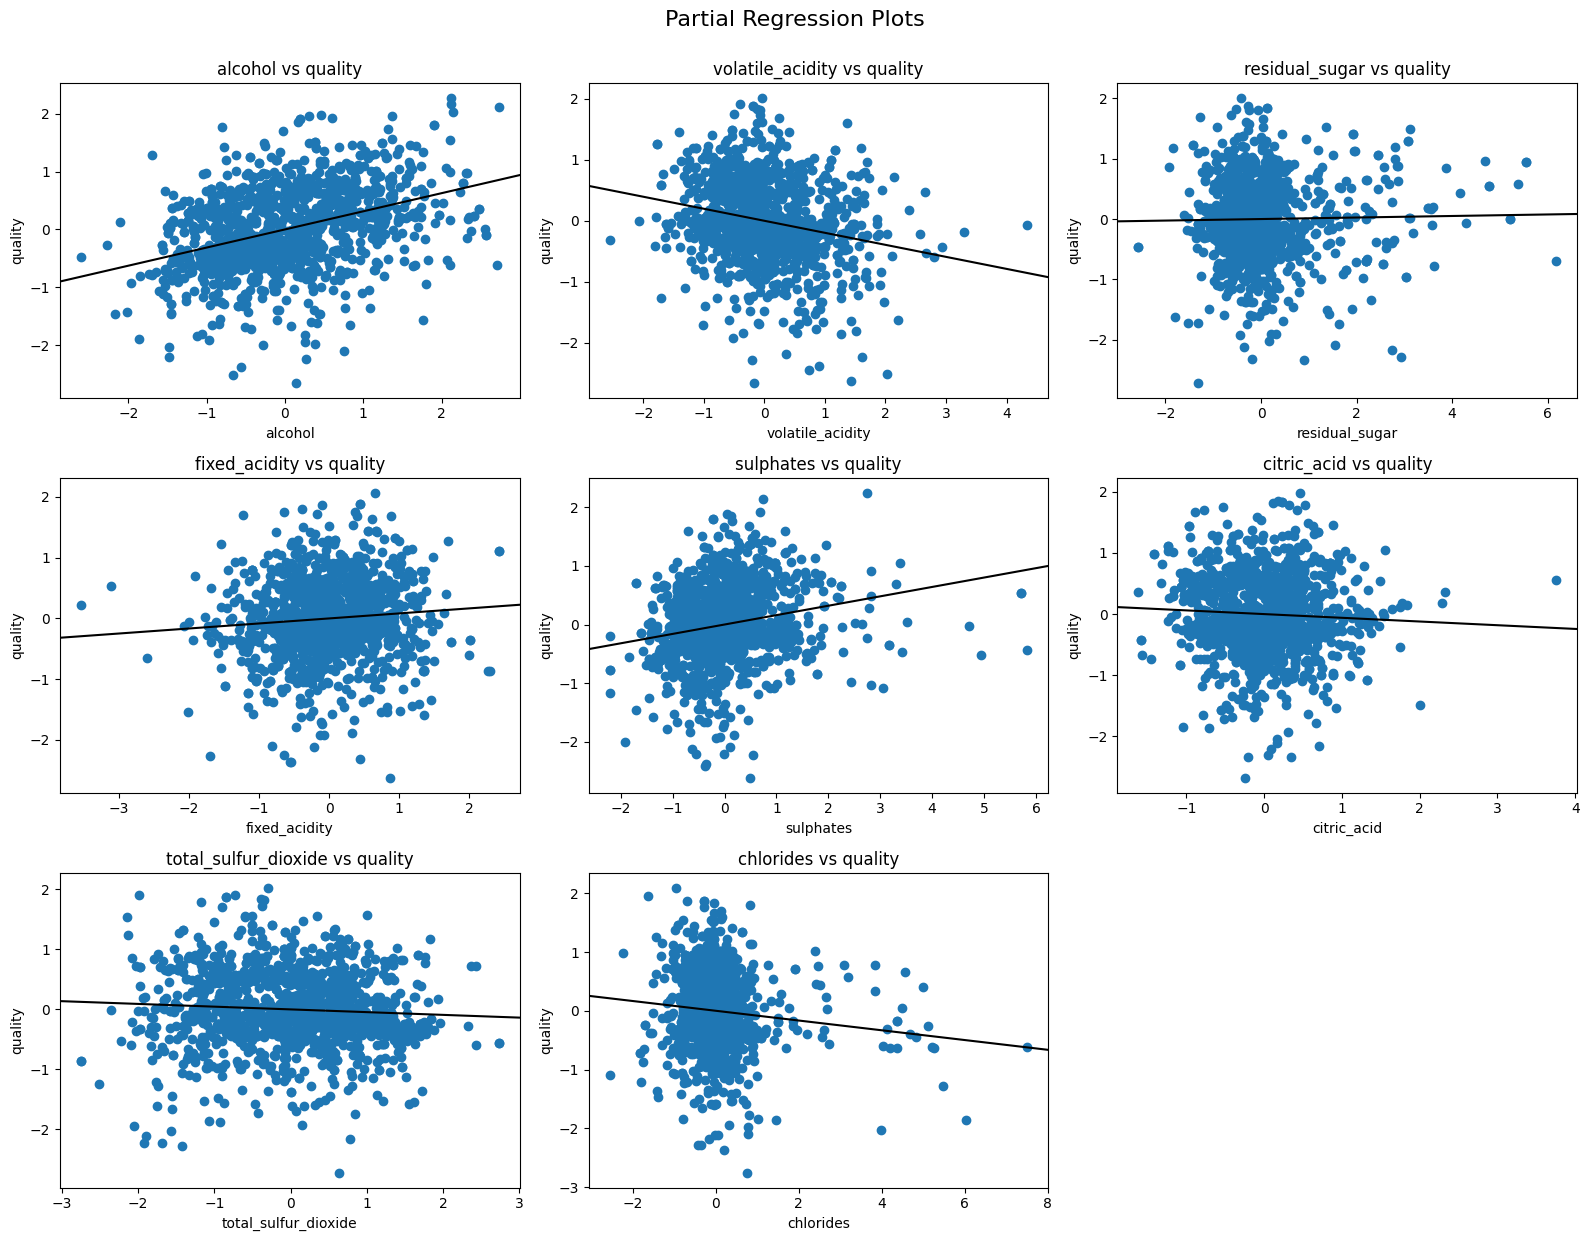

In [232]:
predictors = X_train_const.columns.drop("const")

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, predictor in enumerate(predictors):
    ax = axes[i]
    plot_partregress(
        endog='quality',
        exog_i=predictor,
        exog_others=[p for p in predictors if p != predictor],
        data=X_train_const.assign(quality=y_train),
        ax=ax,
        obs_labels=False  
    )
    ax.set_xlabel(predictor)
    ax.set_ylabel("quality")
    ax.set_title(f"{predictor} vs quality")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Partial Regression Plots", fontsize=16, y=1.03)
plt.show()


**7.4 Confidence Intervals**

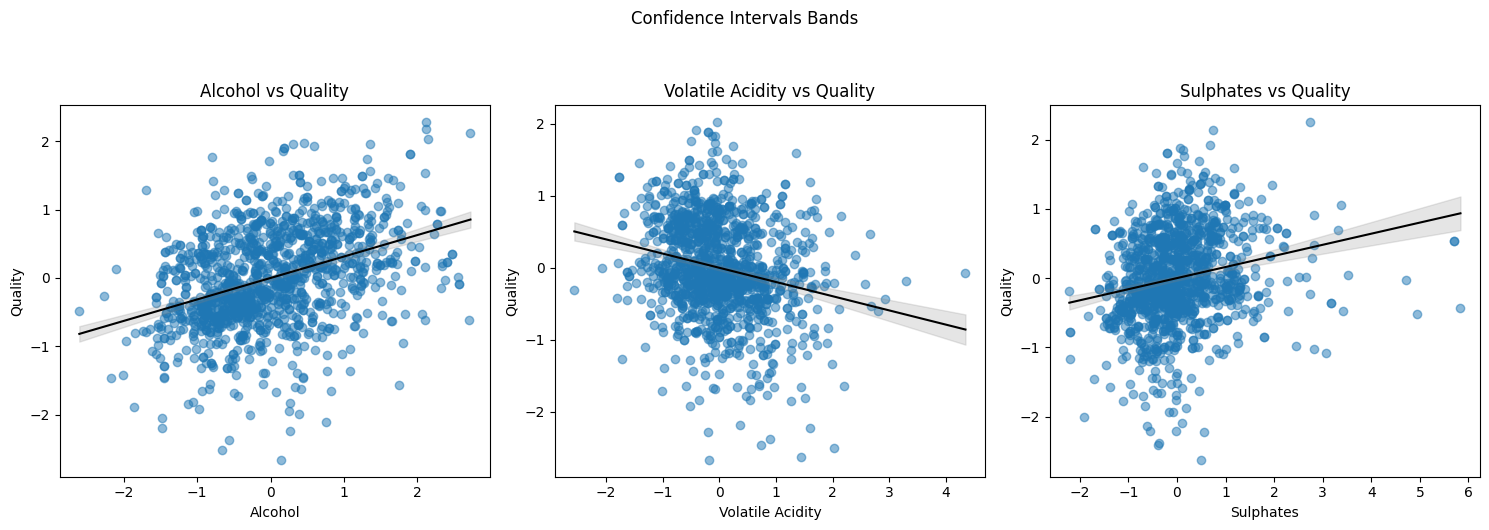


95% Confidence Intervals:
alcohol         [0.272, 0.355]
volatile_acidity [-0.245, -0.150]
sulphates       [0.119, 0.202]


In [233]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
important_vars = ['alcohol', 'volatile_acidity', 'sulphates']

for i, predictor in enumerate(important_vars):
    others = [col for col in X_train_const.columns if col != predictor]
    y_resid = sm.OLS(y_train, X_train_const[others]).fit().resid
    x_resid = sm.OLS(X_train_const[predictor], X_train_const[others]).fit().resid
    
    x_range = np.linspace(x_resid.min(), x_resid.max(), 100)
    y_pred = sm.OLS(y_resid, sm.add_constant(x_resid)).fit().get_prediction(sm.add_constant(x_range))
    
    axes[i].scatter(x_resid, y_resid, alpha=0.5)
    axes[i].plot(x_range, y_pred.predicted_mean, color='black', lw=1.5)
    axes[i].fill_between(x_range, *y_pred.conf_int(alpha=0.05).T, color='gray', alpha=0.2)
    
    title = predictor.replace('_', ' ').title()
    axes[i].set(xlabel=title, ylabel='Quality', title=f'{title} vs Quality')

plt.suptitle("Confidence Intervals Bands", fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

print("\n95% Confidence Intervals:")
for var in important_vars:
    print(f"{var:15} [{model.conf_int(alpha=0.05).loc[var, 0]:.3f}, {model.conf_int(alpha=0.05).loc[var, 1]:.3f}]")

The confidence intervals (shown by the gray shading) are narrowest in the middle of each plot where we have the most data points, and widen at the extremes where data is sparse. For alcohol [0.272, 0.355], volatile acidity [-0.245, -0.150], and sulphates [0.119, 0.202], these precise intervals indicate we're most confident about our predictions in the middle ranges of each variable, but our certainty decreases at very high or low values where we have fewer observations.


**7.5 Residuals Plot**

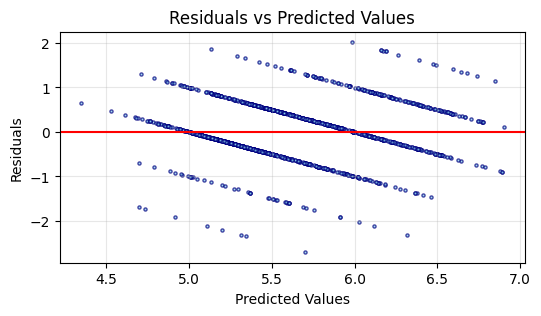


Residual Statistics:
Mean: 0.000
Standard Deviation: 0.652


In [234]:
y_pred = model.predict(X_train_const)
residuals = y_train - y_pred

plt.figure(figsize=(6, 3))
plt.scatter(y_pred, residuals, color='skyblue', edgecolor='navy', alpha=0.7, s=5)  # Added s=10 for smaller points
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nResidual Statistics:")
print(f"Mean: {residuals.mean():.3f}")
print(f"Standard Deviation: {residuals.std():.3f}")

To assess whether the assumptions of linear regression are met, we examine the residuals vs predicted values plot. In a well-fitting model, residuals should be randomly scattered around zero with a consistent spread. This supports the assumptions of linearity (a straight-line relationship between predictors and response) and homoscedasticity (constant variance of residuals across predicted values).

In this plot, the residuals have a mean of 0 as expected, but they form a clear diagonal pattern and spread more as predicted values increase. This suggests violations of both linearity and constant variance assumptions. The increasing spread reflects heteroscedasticity, while the structured pattern implies the model may be missing non-linear relationships. The residual standard deviation of 0.652 indicates that the model explains part of the variation in wine quality, but a considerable amount remains unexplained. 

### 8. HYPOTHESIS RESULTS

Alcohol and Quality:
* Rejects Null Hypothesis (H0) that alcohol content does not significantly affect wine quality. 
* Supports Alternative Hypothesis (H1) that higher alcohol content is associated with higher wine quality. 

Volatile Acidity and Quality:
* Rejects Null Hypothesis (H0) that volatile acidity levels do not significantly affect wine quality. 
* Supports Alternative Hypothesis (H1) that higher volatile acidity is associated with lower wine quality. 

### 9. MODEL VALIDATION 

**9.1 Assessment of Model Performance**

In [235]:
X_test_const = sm.add_constant(X_test_scaled[columns_to_transform])
y_pred = model.predict(X_test_const)

ss_tot = ((y_test - y_test.mean()) ** 2).sum()
ss_res = ((y_test - y_pred) ** 2).sum()
r2_test = 1 - (ss_res / ss_tot)

y_train_pred = model.predict(X_train_const)
mse_train = ((y_train - y_train_pred) ** 2).mean()
mse_test = ((y_test - y_pred) ** 2).mean()

print("\nModel Performance:")
print(f"Training R-squared: {model.rsquared:.3f}")
print(f"Test R-squared: {r2_test:.3f}")
print(f"Training MSE: {mse_train:.3f}")
print(f"Test MSE: {mse_test:.3f}")


Model Performance:
Training R-squared: 0.349
Test R-squared: 0.382
Training MSE: 0.425
Test MSE: 0.399


**R-Squared:** When applied to the hold-out (test) data, the model explains approximately 38% of the variance in wine quality (R² = 0.382), compared to 35% in the training set. This slight improvement in explanatory power suggests that the model has good generalisation capability and the relationships identified in the training data transfer well to unseen data. 

**Mean Squared Error:** The test set shows a slightly lower mean squared error (MSE = 0.399) compared to the training set (MSE = 0.425), which is a positive indication that the model is not overfitting. 


**9.2 Predicted vs Actual Plot**

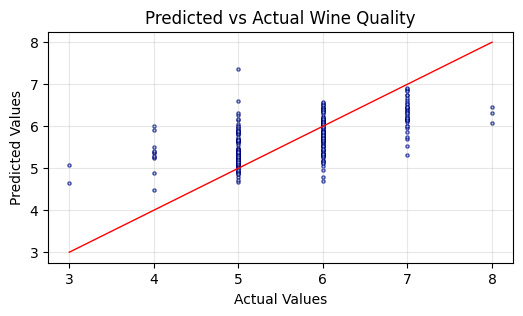

In [236]:
plt.figure(figsize=(6, 3))
plt.scatter(y_test, y_pred, color='skyblue', edgecolor='navy', alpha=0.7, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r-', lw=1)  
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Wine Quality')
plt.grid(True, alpha=0.3)
plt.show()

This visualisation illustrates how well our statistical model explains wine quality based on its measured features. The x-axis displays expert-assigned quality scores, while the y-axis shows the quality scores our model estimates using these variables. The red diagonal line represents perfect alignment between actual and estimated scores. The scatter of points around this line reveals that while these variables help explain wine quality ratings, they tell only part of the story, the variation suggests that expert ratings are influenced by additional factors beyond the measured features of the wine.

### 10. CONCLUSION AND IMPROVEMENTS


**Conclusions** 
1. **Key Variables and Quality**
    - Higher alcohol improve wine quality (supports alternative hypothesis)
    - Lower volatile acidity improves wine quality (supports alternative hypothesis)
    - Higher sulfates improve wine quality 


2. **Model Performance**
    - The model explains 35% of variation in wine quality in training data and 38% in hold-out data. 


**Suggested Improvements** 

1. **Address Non-Linear Relationships:** The current linear model assumes straight-line relationships, but implementing polynomial regression, spline regression, or generalised additive models could better capture complex non-linear patterns between features and quality that our linear model might miss. 

2. **Classification:** Grouping the wine quality into categories such as Poor, Good, and Excellent. This enables the use of classification models, such as logistic regression. This approach might better align with how wine quality is practically assessed in the industry and could provide more actionable insights.

3. **Improve Transformations:** Beyond standard log transformations, exploring more flexible options like the Box-Cox transformation to address highly skewed variables. Better handling of skew can improve model assumptions and performance.

4. **Variable Interactions**: Given the chemical nature of wine composition, exploring interactions between variables could be valuable. For example, the relationship between acids and pH, or how alcohol content might moderate the effect of other features. This could provide deeper insights into how combinations of features influence quality ratings.

5. **Regularisation:**  Regularisation techniques (Lasso, Ridge, or Elastic Net) could be explored to potentially improve the model further, although they may not be necessary given the current model's stable performance across both training and test sets.



